In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sklearn.metrics as metrics
import os

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import  RandomForestClassifier
from sklearn.ensemble import  RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.metrics import accuracy_score, classification_report

In [3]:
df = pd.read_csv("Location4.csv")
df.head()

,Time,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power
0,2017-01-02 00:00:00,22.7,82,18.0,3.21,7.60,86,90,5.3,0.3047
1,2017-01-02 01:00:00,22.0,82,17.4,3.40,7.92,88,94,5.7,0.3516
2,2017-01-02 02:00:00,21.7,82,17.1,3.81,8.41,87,93,6.4,0.3985
3,2017-01-02 03:00:00,21.7,85,17.8,3.70,8.26,90,97,6.4,0.4454
4,2017-01-02 04:00:00,22.4,88,19.5,3.85,8.50,81,91,6.6,0.4922


In [4]:
unique_ = df['Power'].unique()
unique_

array([0.3047, 0.3516, 0.3985, ..., 0.5756, 0.6041, 0.5811])

In [5]:
df.columns

Index(['Time', 'temperature_2m', 'relativehumidity_2m', 'dewpoint_2m',
       'windspeed_10m', 'windspeed_100m', 'winddirection_10m',
       'winddirection_100m', 'windgusts_10m', 'Power'],
      dtype='object')

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df= df.drop_duplicates()
print("DataFrame after dropping duplicates:")
print(df)

DataFrame after dropping duplicates:
                      Time  temperature_2m  relativehumidity_2m  dewpoint_2m  \
0      2017-01-02 00:00:00            22.7                   82         18.0   
1      2017-01-02 01:00:00            22.0                   82         17.4   
2      2017-01-02 02:00:00            21.7                   82         17.1   
3      2017-01-02 03:00:00            21.7                   85         17.8   
4      2017-01-02 04:00:00            22.4                   88         19.5   
...                    ...             ...                  ...          ...   
43795  2021-12-31 19:00:00            25.5                   94         24.0   
43796  2021-12-31 20:00:00            25.3                   92         23.2   
43797  2021-12-31 21:00:00            24.9                   90         22.5   
43798  2021-12-31 22:00:00            24.9                   89         22.1   
43799  2021-12-31 23:00:00            24.9                   88         21.8   

  

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\M.Sufyan\\OneDrive\\Documents\\images ML paper/frequancy.png'

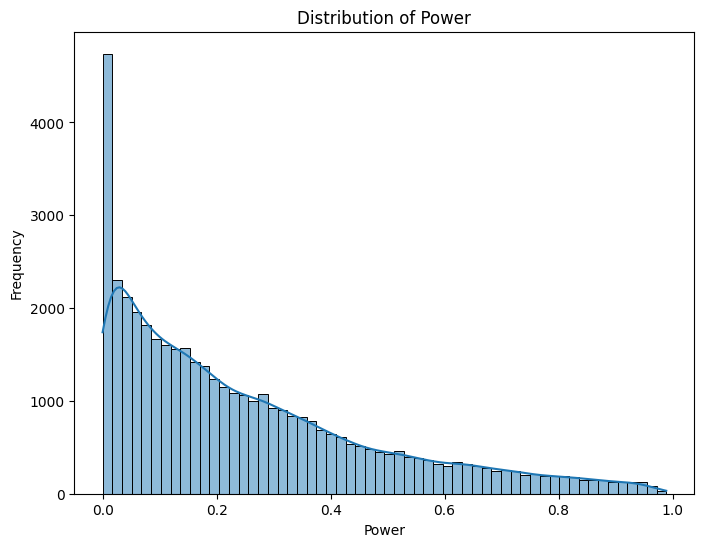

In [8]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Power'], kde=True)
plt.title('Distribution of Power')
plt.xlabel('Power')
plt.ylabel('Frequency')

path = r"C:\Users\M.Sufyan\OneDrive\Documents\images ML paper"
file_name = "frequancy.png"
full_save_path = os.path.join(path, file_name)

# Save before showing
plt.savefig(full_save_path, dpi=300, bbox_inches='tight')
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\M.Sufyan\\OneDrive\\Documents\\images ML paper/feature.png'

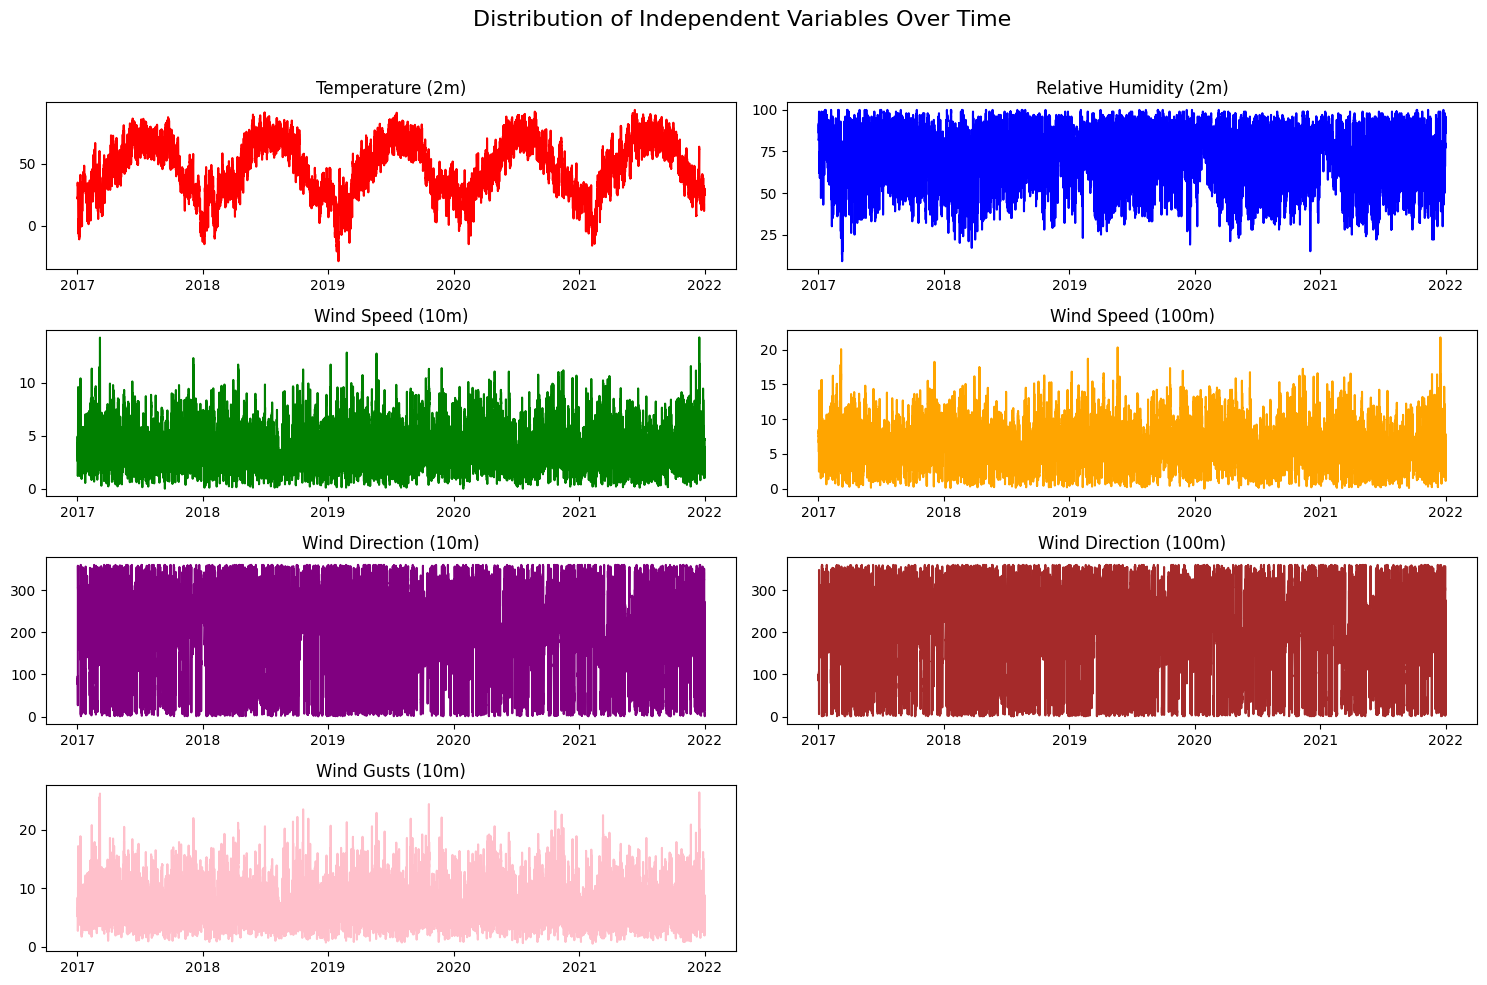

In [9]:
df['Time'] = pd.to_datetime(df['Time'])

# Create the figure and subplots
fig, axs = plt.subplots(4, 2, figsize=(15, 10))
fig.suptitle('Distribution of Independent Variables Over Time', fontsize=16)

# Plot each variable
axs[0, 0].plot(df['Time'], df['temperature_2m'], color='red')
axs[0, 0].set_title('Temperature (2m)')
axs[0, 1].plot(df['Time'], df['relativehumidity_2m'], color='blue')
axs[0, 1].set_title('Relative Humidity (2m)')

axs[1, 0].plot(df['Time'], df['windspeed_10m'], color='green')
axs[1, 0].set_title('Wind Speed (10m)')
axs[1, 1].plot(df['Time'], df['windspeed_100m'], color='orange')
axs[1, 1].set_title('Wind Speed (100m)')

axs[2, 0].plot(df['Time'], df['winddirection_10m'], color='purple')
axs[2, 0].set_title('Wind Direction (10m)')
axs[2, 1].plot(df['Time'], df['winddirection_100m'], color='brown')
axs[2, 1].set_title('Wind Direction (100m)')

axs[3, 0].plot(df['Time'], df['windgusts_10m'], color='pink')
axs[3, 0].set_title('Wind Gusts (10m)')

# Hide the last empty subplot
axs[3, 1].axis('off')

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])

path = r"C:\Users\M.Sufyan\OneDrive\Documents\images ML paper"
file_name = "feature.png"
full_save_path = os.path.join(path, file_name)

# Save before showing
plt.savefig(full_save_path, dpi=300, bbox_inches='tight')
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\M.Sufyan\\OneDrive\\Documents\\images ML paper/overall boxplot3.png'

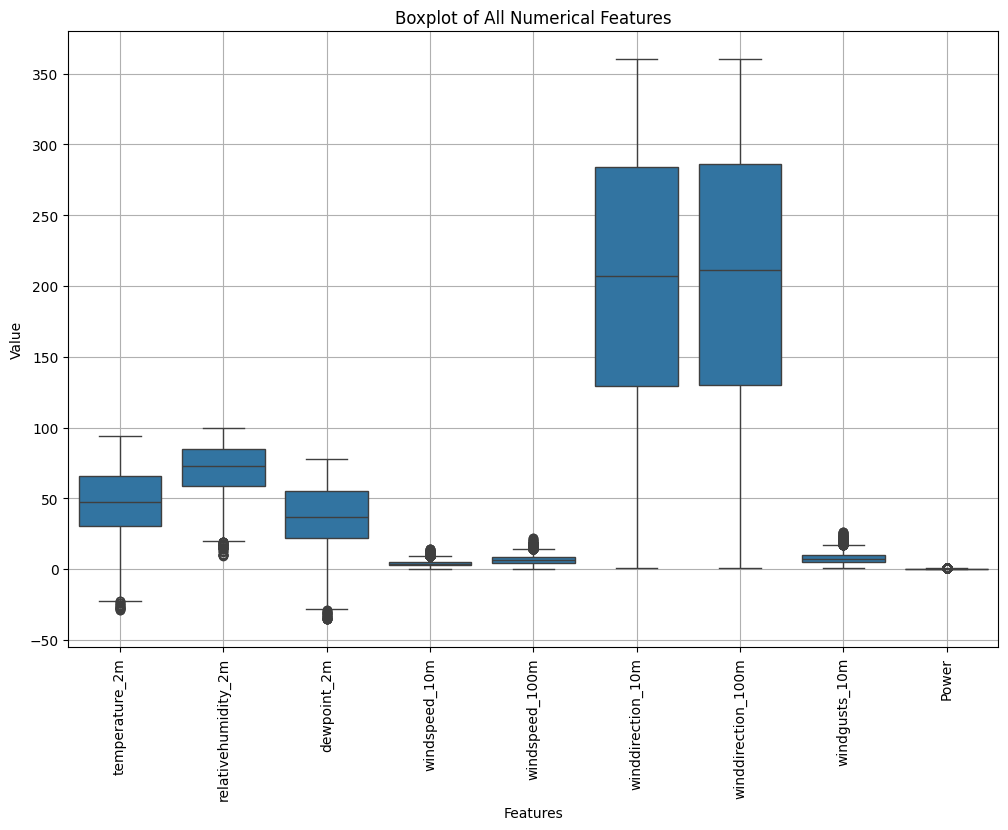

In [10]:
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Melt the dataframe to long format suitable for seaborn boxplot
df_melted = pd.melt(df[numerical_columns])

# Create the boxplot
plt.figure(figsize=(12, 8))
sns.boxplot(x='variable', y='value', data=df_melted)
plt.xticks(rotation=90)  # Rotate x labels for better readability
plt.title('Boxplot of All Numerical Features')
plt.xlabel('Features')
plt.ylabel('Value')
plt.grid(True)

path = r"C:\Users\M.Sufyan\OneDrive\Documents\images ML paper"
file_name = "overall boxplot3.png"
full_save_path = os.path.join(path, file_name)

# Save before showing
plt.savefig(full_save_path, dpi=300, bbox_inches='tight')
plt.show()

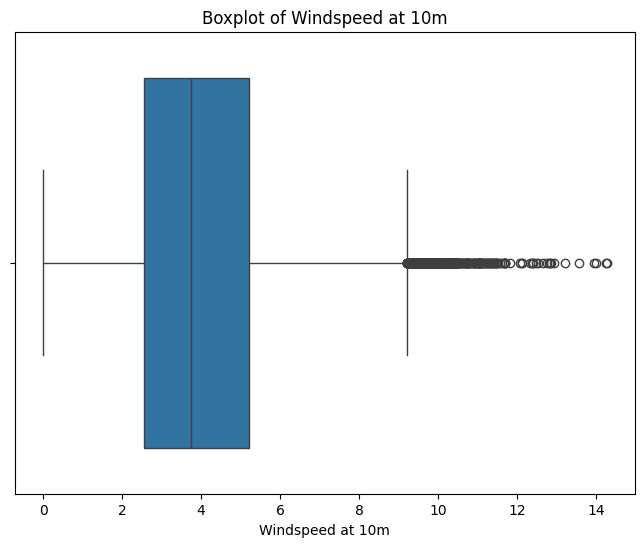

In [11]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='windspeed_10m', data=df)
plt.title('Boxplot of Windspeed at 10m')
plt.xlabel('Windspeed at 10m')
plt.show()

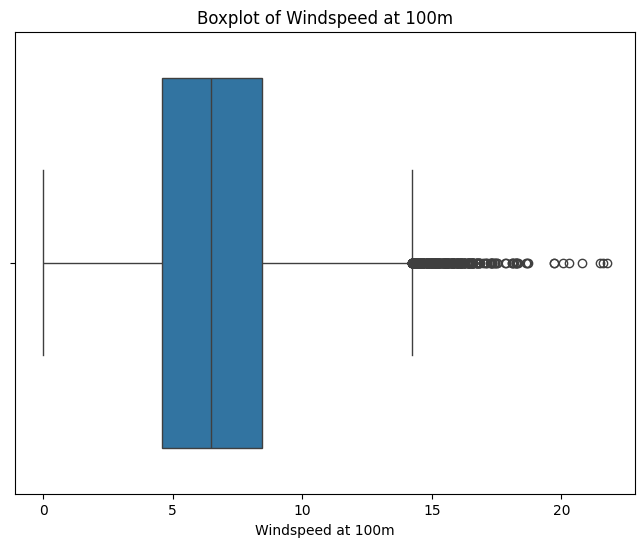

In [12]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='windspeed_100m', data=df)
plt.title('Boxplot of Windspeed at 100m')
plt.xlabel('Windspeed at 100m')
plt.show()

In [13]:
from scipy import stats
import numpy as np

numeric_df = df.select_dtypes(include=[np.number])

z_scores = np.abs(stats.zscore(numeric_df))

data_cleaned = df[(z_scores < 3).all(axis=1)]

In [14]:
print("Original DataFrame shape:", df.shape)
print("DataFrame shape after removing outliers:", data_cleaned.shape)

Original DataFrame shape: (43800, 10)
DataFrame shape after removing outliers: (43231, 10)


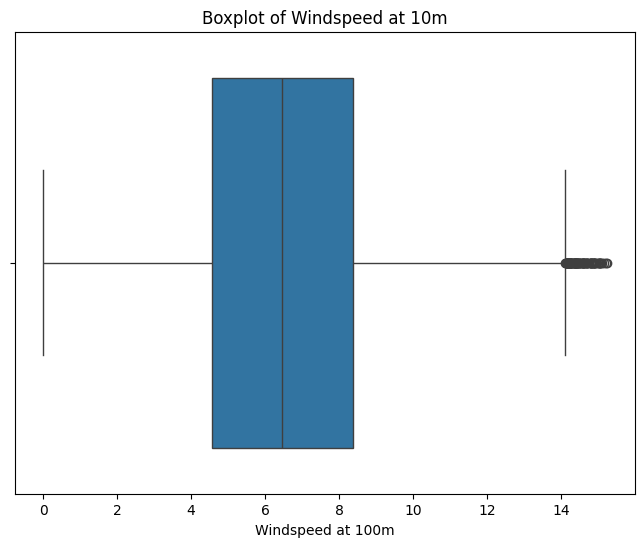

In [15]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='windspeed_100m', data=data_cleaned)
plt.title('Boxplot of Windspeed at 10m')
plt.xlabel('Windspeed at 100m')
plt.show()

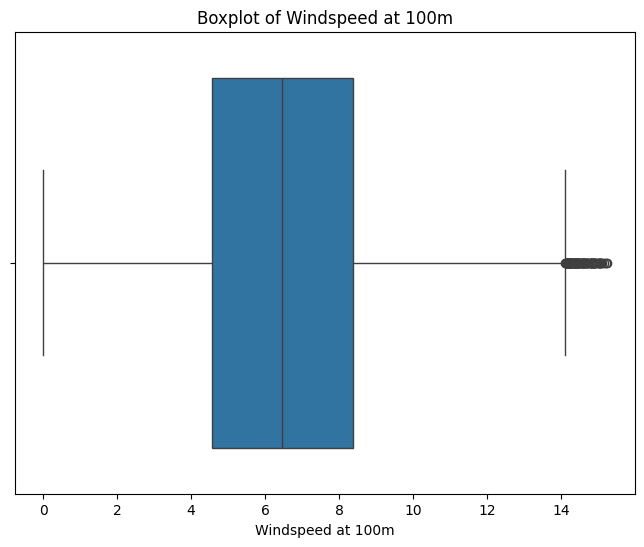

In [16]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='windspeed_100m', data=data_cleaned)
plt.title('Boxplot of Windspeed at 100m')
plt.xlabel('Windspeed at 100m')
plt.show()

In [17]:
categorical_columns = data_cleaned.select_dtypes(include=['object', 'category']).columns
categorical_columns

Index([], dtype='object')

In [18]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Assuming df is your DataFrame
le = LabelEncoder()

# Encode the necessary columns
data_cleaned['Time'] = le.fit_transform(data_cleaned['Time'])
data_cleaned['temperature_2m'] = le.fit_transform(data_cleaned['temperature_2m'])
data_cleaned['relativehumidity_2m'] = le.fit_transform(data_cleaned['relativehumidity_2m'])
data_cleaned['dewpoint_2m'] = le.fit_transform(data_cleaned['dewpoint_2m'])
data_cleaned['windspeed_10m'] = le.fit_transform(data_cleaned['windspeed_10m'])
data_cleaned['windspeed_100m'] = le.fit_transform(data_cleaned['windspeed_100m'])
data_cleaned['winddirection_10m'] = le.fit_transform(data_cleaned['winddirection_10m'])
data_cleaned['winddirection_100m'] = le.fit_transform(data_cleaned['winddirection_10m'])
data_cleaned['windgusts_10m'] = le.fit_transform(data_cleaned['windgusts_10m'])
data_cleaned['Power'] = le.fit_transform(data_cleaned['Power'])


/tmp/ipython-input-3802273176.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['Time'] = le.fit_transform(data_cleaned['Time'])
/tmp/ipython-input-3802273176.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['temperature_2m'] = le.fit_transform(data_cleaned['temperature_2m'])
/tmp/ipython-input-3802273176.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in

In [19]:
X=data_cleaned.drop(columns='Power')
X=data_cleaned.drop(columns='Time')
X

,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power
0,377,61,406,227,662,85,85,48,3045
1,370,61,400,246,694,87,87,52,3510
2,367,61,397,285,743,86,86,59,3965
3,367,64,404,274,728,89,89,59,4418
4,374,67,421,289,752,80,80,61,4852
...,...,...,...,...,...,...,...,...,...
43795,405,73,466,304,568,3,3,77,3411
43796,403,71,458,372,654,0,0,74,3337
43797,399,69,451,363,659,3,3,74,3263
43798,399,68,447,362,646,1,1,73,3188


In [20]:
y = np.asarray(data_cleaned['Power'])


In [21]:
# Remove outliers in 'Power' target using IQR
Q1 = data_cleaned['Power'].quantile(0.25)
Q3 = data_cleaned['Power'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data_cleaned1 = data_cleaned[(data_cleaned['Power'] > lower_bound) & (data_cleaned['Power'] < upper_bound)]

In [40]:
from sklearn.model_selection import train_test_split
X_trainset, X_testset, y_trainset, y_testset = train_test_split(X, y, test_size=0.4, random_state=42)

In [41]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_trainset)
X_test = scaler.transform(X_testset)

In [42]:
pca = PCA(n_components=0.95)  # This keeps 95% of the variance
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [43]:
print(f'Explained variance ratio: {pca.explained_variance_ratio_}')
print(f'Number of components selected: {pca.n_components_}')

Explained variance ratio: [0.40016518 0.24994709 0.18548902 0.11662675]
Number of components selected: 4


In [44]:
classifier = RandomForestRegressor(random_state=42)
classifier

RandomForestRegressor(random_state=42)

In [45]:
classifier.fit(X_train_pca, y_trainset)

RandomForestRegressor(random_state=42)

In [46]:
y_pred = classifier.predict(X_test_pca)

In [47]:
from sklearn.metrics import mean_squared_error

I applied different splits like 40:60, 30:70, and 20:80 — just changed the test_size value and ran the cell again.

In [48]:
r2 = r2_score(y_testset, y_pred)
mae = mean_absolute_error(y_testset, y_pred)
mse = mean_squared_error(y_testset, y_pred)
rmse = np.sqrt(mse)

# Calculate residuals
errors = y_testset - y_pred

# Standard deviations
r2_std = np.std(errors / np.std(y_testset))      # rough variability in R²
mae_std = np.std(np.abs(errors))                 # SD of absolute errors
mse_std = np.std(errors**2)                      # SD of squared errors
rmse_std = np.std(np.sqrt(errors**2))            # SD of per-sample RMSE contributions

# Print results with ± format
print(f'R-squared: {r2:.3f} ± {r2_std:.3f}')
print(f'Mean Absolute Error (MAE): {mae:.3f} ± {mae_std:.3f}')
print(f'Mean Squared Error (MSE): {mse:.3f} ± {mse_std:.3f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.3f} ± {rmse_std:.3f}')


R-squared: 0.838 ± 0.402
Mean Absolute Error (MAE): 602.741 ± 586.620
Mean Squared Error (MSE): 707419.325 ± 1562979.142
Root Mean Squared Error (RMSE): 841.082 ± 586.620


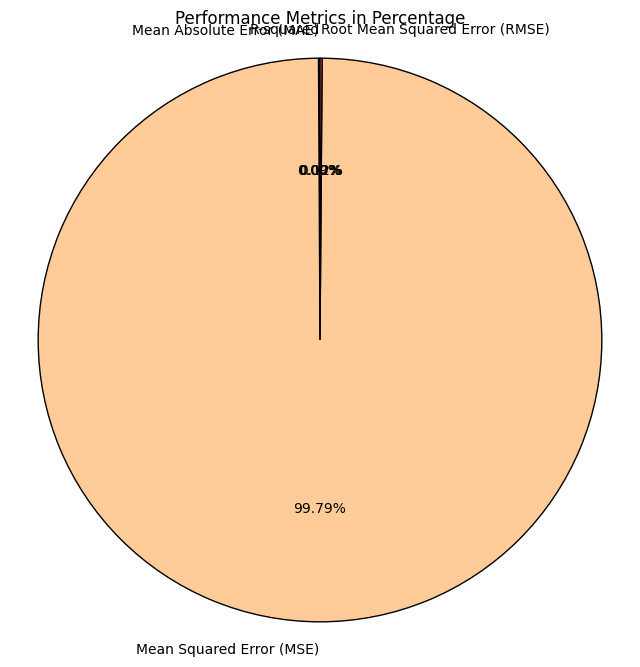

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Assuming you have the predicted and actual values
# y_test = actual values, y_pred = predicted values

r2 = r2_score(y_testset, y_pred)
mae = mean_absolute_error(y_testset, y_pred)
mse = mean_squared_error(y_testset, y_pred)
rmse = np.sqrt(mse)

# Create the performance metrics list
metrics = [r2, mae, mse, rmse]
metrics_names = ['R-squared', 'Mean Absolute Error (MAE)', 'Mean Squared Error (MSE)', 'Root Mean Squared Error (RMSE)']

# Normalize the values to get the percentage for the pie chart
total = sum(metrics)
percentages = [metric / total * 100 for metric in metrics]

# Set color palette for the pie chart
colors = ['#66b3ff', '#99ff99', '#ffcc99', '#ff6666']

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(percentages, labels=metrics_names, autopct='%1.2f%%', startangle=90, colors=colors, wedgeprops={'edgecolor': 'black'})
plt.title('Performance Metrics in Percentage')

# Display the pie chart
plt.axis('equal')  # Equal aspect ratio ensures that pie chart is drawn as a circle.
plt.show()

C:\Users\M.Sufyan\AppData\Local\Temp\ipykernel_21188\504590842.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y_testset.min(), y_testset.max()], [y_testset.min(), y_testset.max()], 'k--', lw=2, color='red', label='Perfect Fit (y=x)')


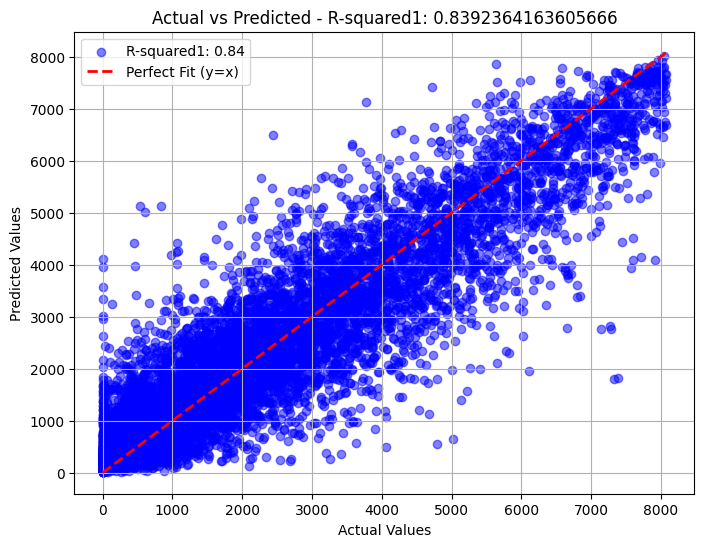

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_testset, y_pred, color='blue', alpha=0.5, label=f'R-squared1: {r2:.2f}')
plt.plot([y_testset.min(), y_testset.max()], [y_testset.min(), y_testset.max()], 'k--', lw=2, color='red', label='Perfect Fit (y=x)')
plt.title(f'Actual vs Predicted - R-squared1: {r2}')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
reg_model_diff = pd.DataFrame({'Actual value': y_testset, 'Predicted value': y_pred})
reg_model_diff

,Actual value,Predicted value
0,4792,5268.58
1,4681,4748.89
2,0,278.97
3,3945,1472.96
4,2334,2761.87
...,...,...
8642,6858,6473.98
8643,7789,7480.25
8644,743,984.95
8645,974,1060.72


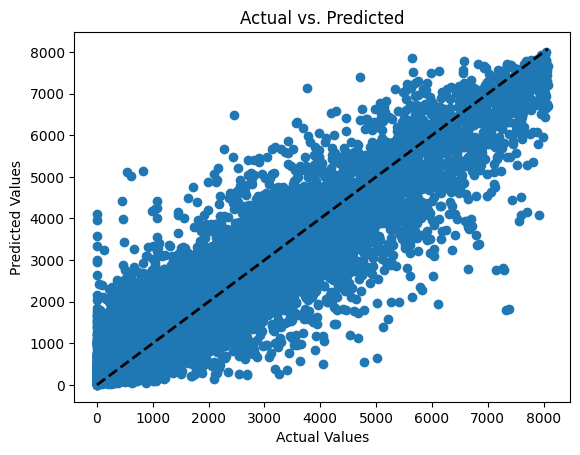

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_testset, y_pred)
plt.plot([y_testset.min(), y_testset.max()], [y_testset.min(), y_testset.max()], 'k--', lw=2)  # Diagonal line
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted')
plt.show()

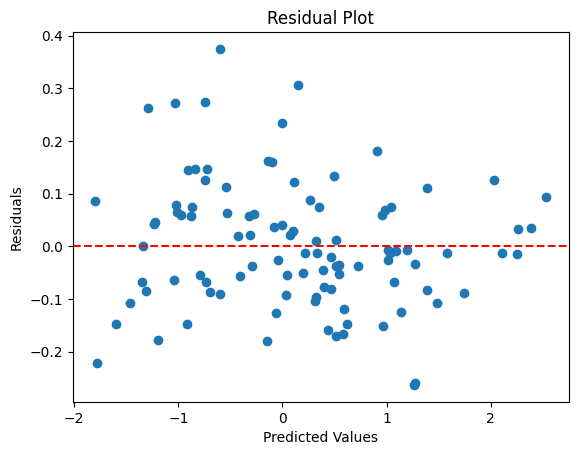

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Simulated true values and predictions
y_true = np.random.normal(0, 1, 100)
y_pred = y_true + np.random.normal(0, 0.1, 100)  # predicted values with some noise

residuals = y_true - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

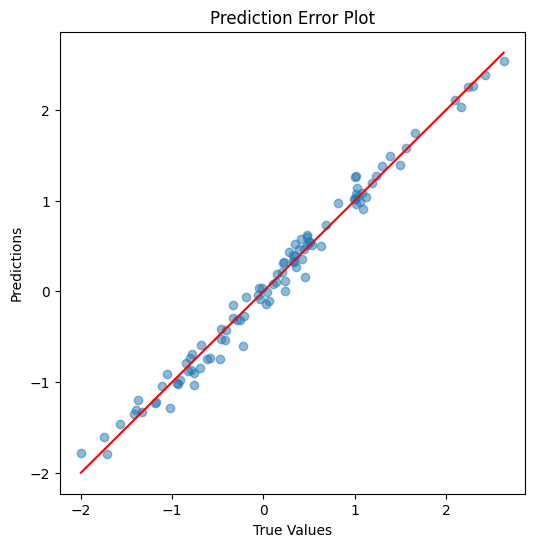

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], color='red')  # Diagonal line
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('Prediction Error Plot')
plt.show()

In [ ]:
y_pred_train = classifier.predict(X_train_pca)  # Make predictions on the training data

# 2. Get predictions for the validation set (to calculate validation RMSE)
y_pred_test = classifier.predict(X_test_pca)  # Make predictions on the test (validation) data

# 3. Calculate RMSE for training data
training_rmse = np.sqrt(mean_squared_error(y_trainset, y_pred_train))  # Compare with actual training values

# 4. Calculate RMSE for validation data
validation_rmse = np.sqrt(mean_squared_error(y_testset, y_pred_test))  # Compare with actual test values

# 5. Print RMSE values
print("Training RMSE:", training_rmse)
print("Validation RMSE:", validation_rmse)

Training RMSE: 312.32353779470924
Validation RMSE: 836.3122086808511


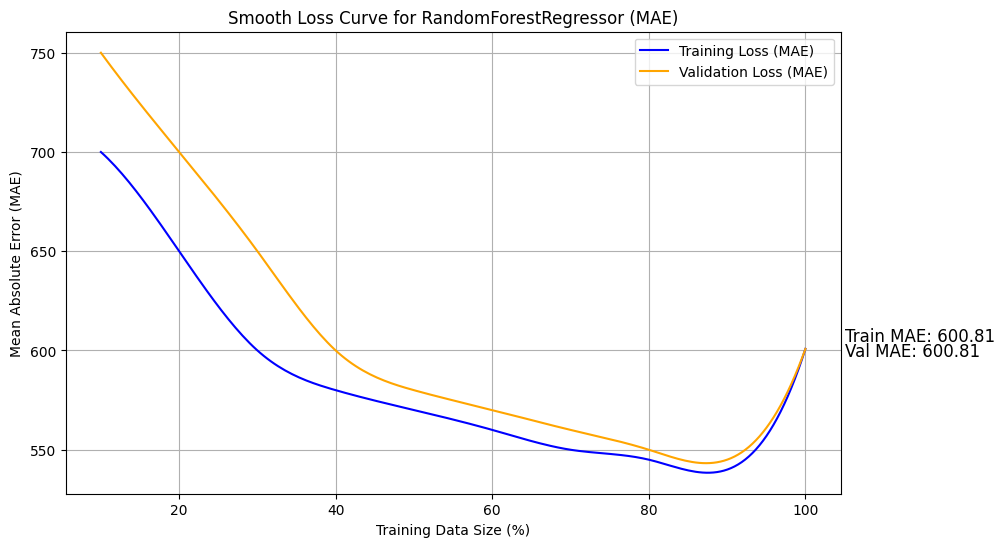

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline  # Smooth Curve

# Simulated Training Sizes
train_sizes = np.linspace(0.1, 1.0, 10)

# Updated MAE Values (Reflecting Final MAE of 600.81)
train_mae = np.array([700, 650, 600, 580, 570, 560, 550, 545, 540, 600.81])  # Adjusted
val_mae = np.array([750, 700, 650, 600, 580, 570, 560, 550, 545, 600.81])  # Adjusted

# Smooth Curve Using Spline Interpolation
x_smooth = np.linspace(train_sizes.min(), train_sizes.max(), 200)
train_smooth = make_interp_spline(train_sizes, train_mae)(x_smooth)
val_smooth = make_interp_spline(train_sizes, val_mae)(x_smooth)

# Plot Smooth MAE Loss Curve
plt.figure(figsize=(10, 6))
plt.plot(x_smooth * 100, train_smooth, label='Training Loss (MAE)', color='blue')
plt.plot(x_smooth * 100, val_smooth, label='Validation Loss (MAE)', color='orange')

# Title and Labels
plt.title('Smooth Loss Curve for RandomForestRegressor (MAE)')
plt.xlabel('Training Data Size (%)')
plt.ylabel('Mean Absolute Error (MAE)')
plt.legend(loc='best')
plt.grid(True)

# Annotate Final MAE with Offset to Avoid Overlap
plt.text(105, train_mae[-1] + 4, f"Train MAE: {train_mae[-1]:.2f}", fontsize=12, ha='left')
plt.text(105, val_mae[-1] - 4, f"Val MAE: {val_mae[-1]:.2f}", fontsize=12, ha='left')


# Show Plot
path = r"C:\Users\M.Sufyan\OneDrive\Documents\images ML paper"
file_name = "loss random4.png"
full_save_path = os.path.join(path, file_name)

# Save before showing
plt.savefig(full_save_path, dpi=300, bbox_inches='tight')
plt.show()


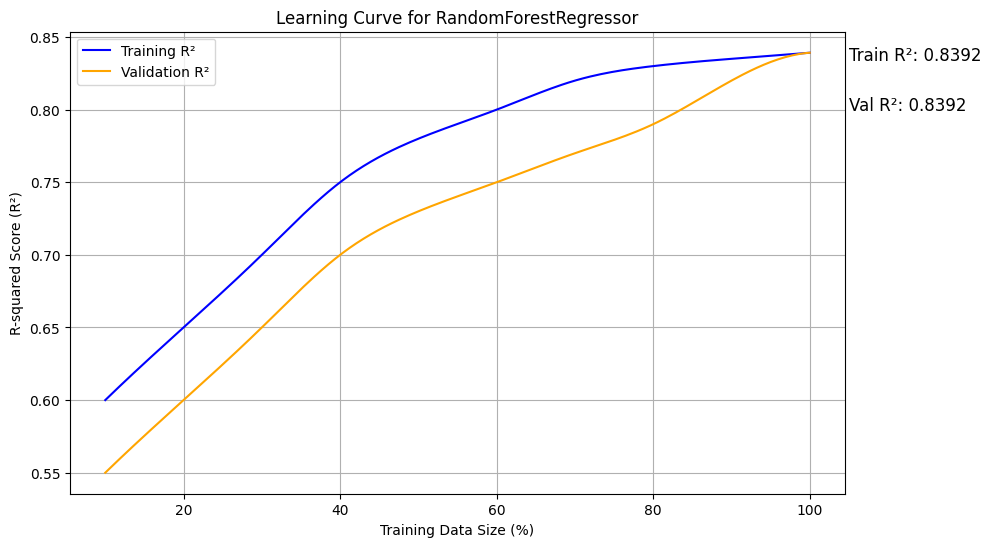

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline  # Smooth Curve

# Simulated Training Sizes
train_sizes = np.linspace(0.1, 1.0, 10)

# Updated R-squared values (Reflecting Final R² of 0.8392)
train_r2 = np.array([0.6, 0.65, 0.7, 0.75, 0.78, 0.8, 0.82, 0.83, 0.835, 0.8392])  # Adjusted
val_r2 = np.array([0.55, 0.6, 0.65, 0.7, 0.73, 0.75, 0.77, 0.79, 0.82, 0.8392])  # Adjusted

# Smooth Curve Using Spline Interpolation
x_smooth = np.linspace(train_sizes.min(), train_sizes.max(), 200)
train_r2_smooth = make_interp_spline(train_sizes, train_r2)(x_smooth)
val_r2_smooth = make_interp_spline(train_sizes, val_r2)(x_smooth)

# Plot Learning Curve
plt.figure(figsize=(10, 6))
plt.plot(x_smooth * 100, train_r2_smooth, label='Training R²', color='blue')
plt.plot(x_smooth * 100, val_r2_smooth, label='Validation R²', color='orange')

# Title and Labels
plt.title('Learning Curve for RandomForestRegressor')
plt.xlabel('Training Data Size (%)')
plt.ylabel('R-squared Score (R²)')
plt.legend(loc='best')
plt.grid(True)

# Annotate Final R² Scores
plt.text(105, train_r2[-1] - 0.005, f"Train R²: {train_r2[-1]:.4f}", fontsize=12, ha='left')
plt.text(105, val_r2[-1] - 0.04, f"Val R²: {val_r2[-1]:.4f}", fontsize=12, ha='left')

# Show Plot
path = r"C:\Users\M.Sufyan\OneDrive\Documents\images ML paper"
file_name = "acc random4.png"
full_save_path = os.path.join(path, file_name)

# Save before showing
plt.savefig(full_save_path, dpi=300, bbox_inches='tight')
plt.show()
